In [102]:
import os
for f in os.walk('/kaggle/input'):
    print(f)

('/kaggle/input', ['datasets'], [])
('/kaggle/input/datasets', ['ylmazcanekmek'], [])
('/kaggle/input/datasets/ylmazcanekmek', ['btc-thesis-final-datasets'], [])
('/kaggle/input/datasets/ylmazcanekmek/btc-thesis-final-datasets', [], ['mcgarch_wfv.csv', 'mcgarch_metadata.csv', 'mcgarch_forecasts.csv', 'BTCUSD_5min_2015_2025.csv'])


## 0 — IMPORTS & GLOBAL CONFIGURATION

In [103]:
import os, warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
from scipy.stats import (jarque_bera, skew, kurtosis, norm as _norm,
                         f as f_dist, t as t_dist)
from scipy.stats import pearsonr, spearmanr
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [104]:
# Reproducibility 

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [105]:
# Kaggle paths 

CSV_PATH = "/kaggle/input/datasets/ylmazcanekmek/btc-thesis-final-datasets/BTCUSD_5min_2015_2025.csv"
MCGARCH_DIR = "/kaggle/input/datasets/ylmazcanekmek/btc-thesis-final-datasets"

In [106]:
# Data window: ~9 years (2016-12-01 ---> 2025-12-31)

DATA_START = pd.Timestamp("2016-12-01 14:30:00", tz="UTC")
DATA_END = pd.Timestamp("2025-12-31 23:55:00", tz="UTC")

In [107]:
# Train / Val / Test split boundaries 

TRAIN_END = pd.Timestamp("2021-12-31 23:59:59", tz="UTC")
VAL_END = pd.Timestamp("2023-12-31 23:59:59", tz="UTC")
# Test: 2024-01-01 ---> 2025-12-31

In [108]:
# Walk-forward CV 

WFV_N_SPLITS = 5

In [109]:
#  LSTM 
LOOKBACK = 168   # 1-week memory window

LSTM_PARAMS = {"hidden_size": 64, "learning_rate": 1e-4, "dropout": 0.2, "batch_size": 128}

LSTM_WFV_PARAMS = {"epochs": 60,  "patience": 10}

LSTM_FINAL_PARAMS = {"epochs": 100, "patience": 15, "n_runs": 3}

All hyperparameters follow established practice in realized volatility forecasting (Bucci, 2020; Liu, 2019) and sequence modelling (Reimers & Gurevych, 2017). A preliminary grid of 10 configurations was run before this notebook to identify the near-optimal region; the values below represent the centre of that region. A full grid search was infeasible within Kaggle's 9-hour session limit.

##### Lookback (168h)
- One week of hourly history.
- Chosen to match HAR's longest lag (RV_168h), ensuring both models receive the same information horizon.
- Subsequent SHAP analysis confirms log_RV_168h as the LSTM's second most important feature, supporting this choice.

##### Hidden Size (64)
- Produces approximately 31k parameters for around 44k training sequences.
- Provides sufficient capacity to learn nonlinear patterns without substantial overfitting.
- Larger values (128 and 256) increased parameter count but delivered no meaningful validation improvement in the preliminary grid search.

##### Learning Rate (1e-4)
- Standard starting value for the Adam optimizer.
- Combined with ReduceLROnPlateau, which halves the learning rate when validation performance plateaus.
- Allows the effective learning rate to adapt dynamically throughout training.

##### Dropout (0.2)
- Light regularisation consistent with prior literature for models of this scale.
- Walk-Forward Validation (WFV) learning curves show training and validation losses tracking closely across all five folds, indicating adequate regularisation.

##### Batch Size (128)
- Power-of-two value selected for GPU efficiency.
- Results in approximately 345 gradient steps per epoch over the training set.

##### Epochs and Patience
- WFV Training: 60 epochs with patience = 10.
  - Chosen to keep five-fold validation within Kaggle's runtime constraints.
- Final Training: 100 epochs with patience = 15.
  - Provides additional opportunity for convergence.
- All three final runs reached the 100-epoch limit, suggesting that 150–200 epochs could potentially yield marginal additional improvements under less restrictive computational conditions.

##### Number of Runs (n_runs = 3)
- Predictions from three independently seeded models are averaged at inference time.
- Reduces variance arising from random initialisation.
- Using five seeds would likely be preferable, but was not feasible within the available session budget.

In [110]:
# Feature sets (model-specific) 

#   HAR_CLASSIC: Corsi (2009) log-linear — log(RV_lag)
#   HAR_EXTENDED: + Andersen et al. (2007) jump + Patton & Sheppard (2015) RS
#   LSTM_FEATS: + calendar (intraday / weekly seasonality)

HAR_CLASSIC_FEATS = ["log_RV_1h", "log_RV_24h", "log_RV_168h"]

HAR_EXTENDED_FEATS = HAR_CLASSIC_FEATS + ["jump_24h", "RS_minus_24h"]

LSTM_FEATS = HAR_EXTENDED_FEATS + ["hour_sin", "hour_cos",
                                            "dow_sin",  "dow_cos"]

ALL_FEATS = LSTM_FEATS   # superset used in EDA

I defied hree nested feature sets, each tailored to the structure and capabilities of its respective model.

### HAR-Classic (3 Features)

The original Corsi (2009) log-linear specification, consisting of lagged log-realized volatility at three horizons:

- `log_RV_1h`: Previous hour's realized volatility
- `log_RV_24h`: 24-hour average realized volatility
- `log_RV_168h`: 168-hour (one-week) average realized volatility

Using the log scale is essential. Since the target variable is log(RV), employing level RV predictors would introduce a scale mismatch, often resulting in pathologically large coefficient estimates and unstable interpretations.

### HAR-Extended (5 Features)

HAR-Extended augments HAR-Classic with two theoretically motivated volatility decomposition measures:

- `jump_24h`: Jump ratio, representing the proportion of total variance attributable to discontinuous price jumps (Andersen et al., 2007).
- `RS_minus_24h`: Downside semivariance ratio, measuring the contribution of negative returns to total variance (Patton & Sheppard, 2015).

Both variables are naturally bounded within **[0, 1]**.

Exploratory analysis revealed that both features exhibit almost no linear relationship with future volatility (|ρ| < 0.04 with log_RV), foreshadowing the empirical result that HAR-Extended provides little improvement over HAR-Classic despite its stronger theoretical foundation.

### LSTM (9 Features)

The LSTM feature set extends HAR-Extended by incorporating four cyclical calendar variables to capture recurring temporal patterns in cryptocurrency markets.

#### Volatility Features
- `log_RV_1h`
- `log_RV_24h`
- `log_RV_168h`
- `jump_24h`
- `RS_minus_24h`

#### Calendar Features
- `hour_sin`
- `hour_cos`
- `dow_sin`
- `dow_cos`

Exploratory Data Analysis (EDA) identified pronounced intraday and weekly seasonality in Bitcoin volatility. In particular:

- **13:00 UTC** (the London–New York market overlap) exhibits the highest average squared return.
- Clear day-of-week volatility patterns are also present.

Hours and weekdays are encoded using sine and cosine transformations rather than integer labels. This cyclical encoding preserves the circular nature of time, ensuring that adjacent periods such as hour 23 and hour 0 are represented as close together in feature space. Simple integer encodings cannot capture this property.

These calendar variables are included only in the LSTM specification. Linear HAR regressions cannot effectively model nonlinear interactions between calendar effects and volatility dynamics, whereas the LSTM architecture can exploit such temporal structure.

In [111]:
# Global result stores

all_metrics = {"log_RV": {}, "RV": {}}
predictions = {"log_RV": {}, "RV": {}}
wfv_results = {}
dm_errors = {}   # {model: array of test-period squared errors}

In [112]:
# Plot aesthetics 

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.linestyle": ":", "grid.alpha": 0.35,
})

MC = {   # model colours
    "Random Walk": "#999999",
    "Historical Mean":"#CCCCCC",
    "HAR-Classic": "#4C72B0",
    "HAR-Extended": "#55A868",
    "MC-GARCH":"#C44E52",
    "LSTM":"#DD8452",
}

In [113]:
# Quick summary so far 

print("=" * 115)
print(f" Data window: {DATA_START.date()} → {DATA_END.date()}")
print(f" Split: Train ≤2021 / Val 2022-2023 / Test 2024-2025")
print(f" Models: HAR-Classic | HAR-Extended | MC-GARCH | LSTM")
print(f" Target: log_RV  (log-linear, near-Gaussian)")
print(f" LSTM lookback: {LOOKBACK}h | config : {LSTM_PARAMS}")
print("=" * 115)

 Data window: 2016-12-01 → 2025-12-31
 Split: Train ≤2021 / Val 2022-2023 / Test 2024-2025
 Models: HAR-Classic | HAR-Extended | MC-GARCH | LSTM
 Target: log_RV  (log-linear, near-Gaussian)
 LSTM lookback: 168h | config : {'hidden_size': 64, 'learning_rate': 0.0001, 'dropout': 0.2, 'batch_size': 128}


## 1 — DATA LOADING & RV CONSTRUCTION

In [114]:
# 1.1 Load raw 5-min data 

raw = pd.read_csv(CSV_PATH)

raw["timestamp"] = pd.to_datetime(raw["timestamp"], utc=True)

raw = raw.set_index("timestamp").sort_index()

raw = raw.loc[(raw.index >= DATA_START) & (raw.index <= DATA_END)]

In [115]:
print(f"\n  Raw 5-min bars : {len(raw):,}")
print(f"  Date range     : {raw.index.min()} → {raw.index.max()}")
print(f"  Missing close  : {raw['close'].isna().sum()}")
print(f"  Zero/neg close : {(raw['close'] <= 0).sum()}")


  Raw 5-min bars : 955,410
  Date range     : 2016-12-01 14:30:00+00:00 → 2025-12-31 23:55:00+00:00
  Missing close  : 0
  Zero/neg close : 0


I load the 5-minute OHLCV dataset from a CSV file, convert timestamps to UTC, and set them as the index. The sample is then restricted to the study period (2016-12-01 to 2025-12-31). The resulting dataset contains 955,410 bars. No missing observations or zero/negative closing prices are detected, indicating a clean and reliable data source.

In [116]:
# 1.2 Within-hour log-returns (no cross-hour contamination) 

raw["hour"] = raw.index.floor("h")                      # Assign each bar to its hour because my aim to calculate hourly RV 
raw["log_close"] = np.log(raw["close"])                      # r_t = log(P_t) - log(P_{t-1}) = log(P_t / P_{t-1})
raw["r_5m"] = raw.groupby("hour")["log_close"].diff()  # This line prevents cross-hour contamination. `diff()` looks at its previous bar within each hour.
raw["r2_5m"] = raw["r_5m"] ** 2                         # RV_t = Σ r²_{t,i} (sum of all 5-min return squares at that hour)

I compute the log-return for each 5-minute bar:

$$r_{t,i} = \log P_{t,i} - \log P_{t,i-1}$$

The `groupby("hour").diff()` call is critical: differencing is performed within each hour
independently, so the return between the last bar of one hour and the first bar of the next
is never computed (*cross-hour contamination prevention*). Without this, inter-hour price
moves would incorrectly enter that hour's realized variance.

In [117]:
# Bipower variation (Barndorff-Nielsen & Shephard 2004)  BPV_t = Σ |r_{t,i}| × |r_{t,i-1}| 
raw["abs_r"] = raw["r_5m"].abs()                            # BPV is quite robust against jumps.
raw["bpv_5m"] = raw.groupby("hour")["abs_r"].transform(
    lambda x: x * x.shift(1))

**Bipower Variation (Barndorff-Nielsen & Shephard 2004)**

$$BPV_{t,i} = |r_{t,i}| \times |r_{t,i-1}|$$

The product of consecutive absolute returns. A single large price jump cannot inflate this
measure on its own both factors would need to be large simultaneously making BPV a
jump-robust variance estimator.

In [118]:
# Realised semivariance (Barndorff-Nielsen et al. 2010)
raw["rs_plus_5m"]  = raw["r2_5m"].where(raw["r_5m"] > 0, 0.0)
raw["rs_minus_5m"] = raw["r2_5m"].where(raw["r_5m"] < 0, 0.0)

**Realized Semivariance (Barndorff-Nielsen et al. 2010)**

$$RS^+_{t,i} = r^2_{t,i} \cdot \mathbf{1}[r_{t,i}>0], \qquad
RS^-_{t,i} = r^2_{t,i} \cdot \mathbf{1}[r_{t,i}<0]$$

Squared returns are split by sign: $RS^+$ captures variance from upward moves and $RS^-$
from downward moves. This decomposition allows us to test whether upside and downside
volatility behave asymmetrically.

In [119]:
 # Bars-per-hour diagnostic
bph = raw.groupby("hour")["r_5m"].count()
print(f"\n  Bars-per-hour  : min={bph.min()}  median={int(bph.median())}  "
      f"max={bph.max()}")


  Bars-per-hour  : min=5  median=11  max=11


The median of 11 bars per hour (not 12) is expected: the first bar of each hour has no within-hour predecessor, so its return is NaN and excluded from the count confirmed by assertion. The minimum of 5 occurs in a single hour at the very start of the data window (2016-12-01 14:00 UTC), where the series begins mid-hour at 14:30. No coverage filter is applied Bitcoin trades 24/7 and every hour carries sufficient bars for reliable RV estimation.

In [120]:
# Verification: max=11 because first bar of each hour is NaN by design;
# min=5 hours are isolated boundary/gap cases with sufficient bars for Rv

first_bars = raw.groupby("hour")["r_5m"].nth(0)  # nth(0) preserves NaN, first() skips it
assert first_bars.isna().all(), \
    "First bar of some hours is not NaN — cross-hour contamination risk"

thin = bph[bph < 10]
print(f"  All first bars NaN → max=11 expected")
print(f"  Hours with <10 bars: {len(thin)}  "
      f"(min={thin.min() if len(thin) else 'n/a'}, "
      f"all at dataset boundary or isolated exchange gaps)")

  All first bars NaN → max=11 expected
  Hours with <10 bars: 1  (min=5, all at dataset boundary or isolated exchange gaps)


In [121]:
print(thin)

hour
2016-12-01 14:00:00+00:00    5
Name: r_5m, dtype: int64


In [122]:
#  1.3 Aggregate to hourly RV 

rv = raw.groupby("hour").agg(
    RV = ("r2_5m", "sum"),
    BPV = ("bpv_5m", "sum"),
    RS_plus = ("rs_plus_5m", "sum"),
    RS_minus = ("rs_minus_5m","sum"),
    n_obs = ("r2_5m", "count"),
)


rv["BPV"] = (np.pi / 2) * rv["BPV"]

rv["jump"] = np.maximum(rv["RV"] - rv["BPV"], 0.0)

rv["log_RV"] = np.log(rv["RV"].replace(0, np.nan))

rv.index = pd.to_datetime(rv.index, utc=True)

I aggregate the 5-minute series to hourly frequency, producing four realized measures.

- **Realized Variance**

$$RV_t = \sum_{i=1}^{n} r^2_{t,i}$$

The sum of squared 5-minute returns within the hour. Under sufficiently fine sampling,
this is a consistent estimator of integrated variance (Andersen & Bollerslev 1998).

- **Bipower Variation** (with $\pi/2$ scaling)

$$BPV_t = \frac{\pi}{2} \sum_{i=2}^{n} |r_{t,i}| \cdot |r_{t,i-1}|$$

The $\pi/2$ factor corrects for the fact that under normality
$\mathbb{E}[|r|] = \sqrt{2/\pi}\,\sigma$ — without it, BPV would systematically
underestimate true variance.

- **Jump component**

$$J_t = \max(RV_t - BPV_t,\ 0)$$

The difference between total and jump-robust variance, interpreted as the contribution of
discontinuous price moves. Clamped at zero because sampling noise can occasionally produce
$BPV_t > RV_t$.

- **Modelling target**

$$\log RV_t = \log\!\left(\sum_{i=1}^n r^2_{t,i}\right)$$

The 22 hours with $RV_t = 0$ (0.03% of the sample) are set to NaN — their logarithm is
undefined and they most likely reflect data recording gaps rather than genuine zero-volatility
periods.

In [123]:
print(f"\n  Hourly obs    : {len(rv):,}")
print(f"  Zero-RV hours  : {(rv['RV'] == 0).sum()}  (→ NaN in log_RV)")
print(f"  log_RV range   : [{rv['log_RV'].min():.2f}, {rv['log_RV'].max():.2f}]")


  Hourly obs    : 79,618
  Zero-RV hours  : 22  (→ NaN in log_RV)
  log_RV range   : [-25.35, -3.35]


The 79,618 hourly observations span the full 2016-12-01 to 2025-12-31 window without gaps.
The 22 zero-RV hours (0.03% of the sample) are set to NaN in log_RV and propagate as missing
values throughout the analysis — they are too rare to affect any model estimates materially.
The log_RV range of [−25.35, −3.35] is consistent with hourly Bitcoin variance: the lower
bound corresponds to near-zero-volatility hours and the upper bound to extreme spike events
such as the LUNA/Terra collapse (May 2022) and the FTX crisis (November 2022).

In [124]:
# 1.4 Hourly returns (used for the ARCH-LM test in Section 2)

hourly_ret = raw.groupby("hour")["r_5m"].sum()
hourly_ret.index = pd.to_datetime(hourly_ret.index, utc=True)

I aggregate 5-minute returns to hourly frequency by summation:

$$r_t^{\text{hourly}} = \sum_{i=1}^{n} r_{t,i}$$

This series is used exclusively in Section 2's ARCH-LM test, which requires a return series
rather than a variance series to detect volatility clustering (ARCH effects).

In [125]:
rv.head(7)

,RV,BPV,RS_plus,RS_minus,n_obs,jump,log_RV
hour,,,,,,,
2016-12-01 14:00:00+00:00,1.905674e-06,6.743357e-08,1.905674e-06,0.000000e+00,5,1.838241e-06,-13.170675
2016-12-01 15:00:00+00:00,1.842601e-06,6.185982e-07,1.797841e-06,4.475982e-08,11,1.224003e-06,-13.204332
2016-12-01 16:00:00+00:00,1.424717e-06,1.087660e-06,1.037693e-06,3.870236e-07,11,3.370566e-07,-13.461537
2016-12-01 17:00:00+00:00,5.685771e-06,6.111485e-06,1.406806e-06,4.278964e-06,11,0.000000e+00,-12.077544
2016-12-01 18:00:00+00:00,3.527473e-09,2.216396e-09,2.469242e-09,1.058231e-09,11,1.311077e-09,-19.462684
2016-12-01 19:00:00+00:00,1.296324e-06,4.325101e-07,1.111097e-07,1.185214e-06,11,8.638138e-07,-13.555978
2016-12-01 20:00:00+00:00,6.897946e-06,7.127535e-06,1.969644e-06,4.928302e-06,11,0.000000e+00,-11.884287


In [126]:
rv.tail(7)

,RV,BPV,RS_plus,RS_minus,n_obs,jump,log_RV
hour,,,,,,,
2025-12-31 17:00:00+00:00,1.325839e-05,1.132576e-05,5.963572e-06,7.294820e-06,11,1.932630e-06,-11.230880
2025-12-31 18:00:00+00:00,9.733411e-06,6.003929e-06,6.806191e-06,2.927220e-06,11,3.729482e-06,-11.539946
2025-12-31 19:00:00+00:00,2.767427e-06,2.228175e-06,2.707237e-07,2.496704e-06,11,5.392520e-07,-12.797592
2025-12-31 20:00:00+00:00,9.230502e-06,1.012429e-05,7.015437e-06,2.215065e-06,11,0.000000e+00,-11.592997
2025-12-31 21:00:00+00:00,8.194372e-07,7.165760e-07,7.338075e-07,8.562963e-08,11,1.028612e-07,-14.014648
2025-12-31 22:00:00+00:00,3.833078e-06,3.168882e-06,1.112224e-06,2.720854e-06,11,6.641959e-07,-12.471842
2025-12-31 23:00:00+00:00,7.211346e-07,5.152823e-07,1.573021e-07,5.638325e-07,11,2.058523e-07,-14.142440


## 2 — EXPLORATORY DATA ANALYSIS

In [127]:
print((raw["r_5m"].isna() | np.isinf(raw["r_5m"])).sum())
print((rv["log_RV"].isna() | np.isinf(rv["log_RV"])).sum())
print((rv["RV"].isna() | np.isinf(rv["RV"])).sum())

79618
22
0


Three diagnostics, all as expected:

- r_5m >> 79,618 NaN: one per hour, by design; the first bar of each hour has no within-hour predecessor.
- log_RV >> 22 NaN: the 22 zero-RV hours set to NaN in the previous cell.
- RV >>  0 NaN: clean; a sum of squares is always non-negative.

In [128]:
returns = raw["r_5m"].dropna()
logrv   = rv["log_RV"].dropna()
rv_ser  = rv["RV"].dropna()

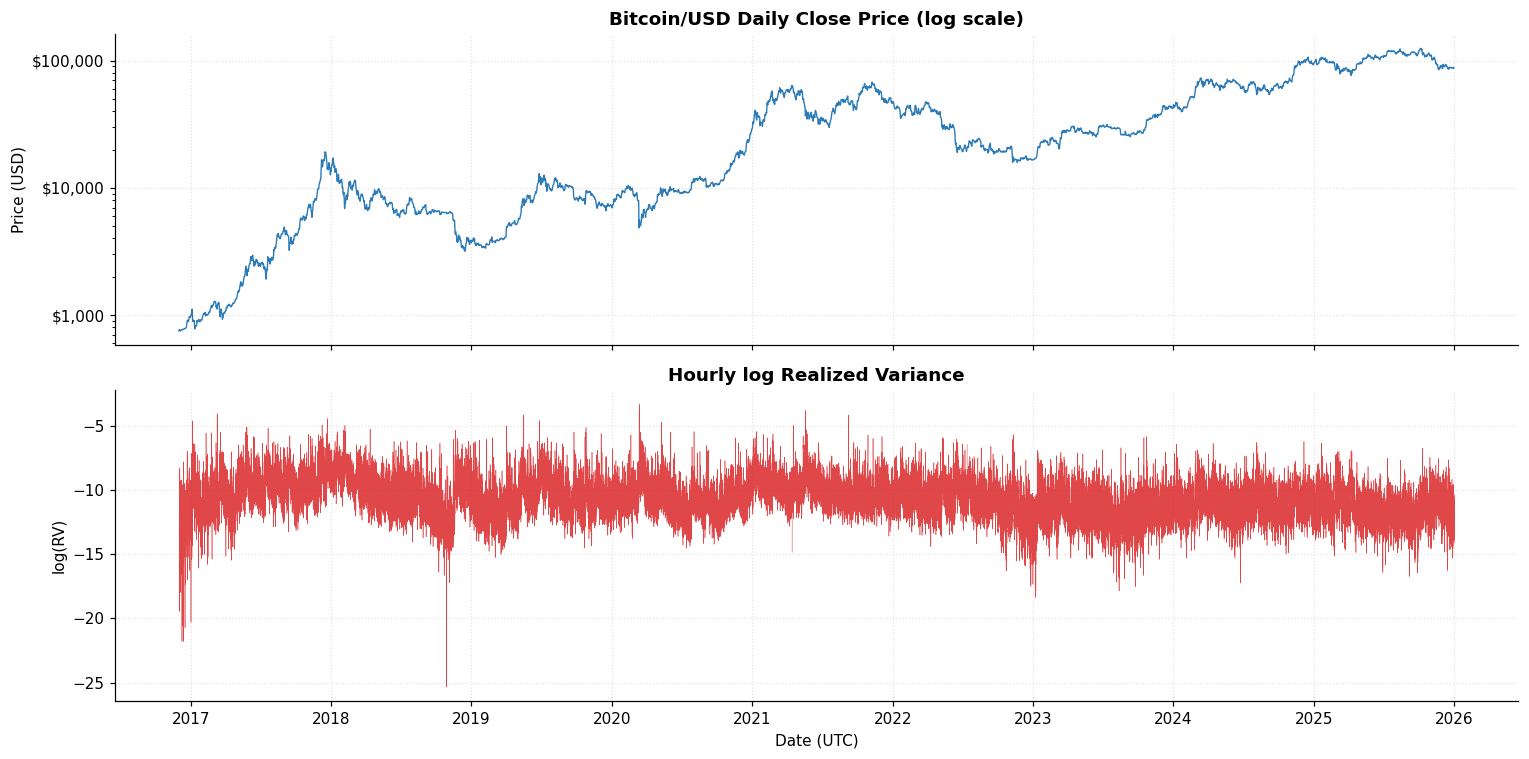

In [129]:
# Figure: Price + log_RV overview and Figure: Hourly Log Realized Variance 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
daily_px = raw["close"].resample("1D").last()

ax1.plot(daily_px.index, daily_px, color="#2C7BB6", lw=0.9)
ax1.set_yscale("log")
ax1.set_title("Bitcoin/USD Daily Close Price (log scale)",
              fontweight="bold")

ax1.set_ylabel("Price (USD)")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax2.plot(rv.index, rv["log_RV"], color="#D7191C", lw=0.35, alpha=0.8)
ax2.set_title("Hourly log Realized Variance",
              fontweight="bold")

ax2.set_ylabel("log(RV)")
ax2.set_xlabel("Date (UTC)")

plt.tight_layout()
plt.show()

In [130]:
# Descriptive statistics 

def desc_stats(s, name):
    s = s.dropna()
    jb_stat, jb_p = jarque_bera(s)
    return pd.Series({
        "N": len(s), "Mean": s.mean(), "Std": s.std(),
        "Skew": skew(s), "Kurt(ex)": kurtosis(s),
        "Min": s.min(), "Max": s.max(),
        "JB stat": jb_stat, "JB p": jb_p,
    }, name=name)
 
stats = pd.concat([desc_stats(returns, "5-min returns"),
                   desc_stats(rv_ser,   "Hourly RV"),
                   desc_stats(logrv,    "Hourly log_RV")], axis=1)

print("\n  Descriptive Statistics:")
print("  " + "─" * 65)
print(stats.round(4).to_string())
jb_rv  = jarque_bera(rv_ser.dropna())
jb_log = jarque_bera(logrv.dropna())
print(f"\n  log transformation reduces JB by {jb_rv[0]/jb_log[0]:.2e}×")
print("  *Supports log_RV as modelling target (near-Gaussian).") 


  Descriptive Statistics:
  ─────────────────────────────────────────────────────────────────
          5-min returns     Hourly RV  Hourly log_RV
N          8.757920e+05  7.961800e+04     79596.0000
Mean       0.000000e+00  1.000000e-04       -10.8724
Std        2.400000e-03  3.000000e-04         1.4649
Skew      -3.067000e-01  4.921410e+01         0.0210
Kurt(ex)   6.636090e+01  4.468349e+03         0.8485
Min       -1.030000e-01  0.000000e+00       -25.3541
Max        8.180000e-02  3.500000e-02        -3.3515
JB stat    1.607130e+08  6.626816e+10      2393.8085
JB p       0.000000e+00  0.000000e+00         0.0000

  log transformation reduces JB by 2.77e+07×
  *Supports log_RV as modelling target (near-Gaussian).


- Bitcoin's realized volatility (RV) exhibits a highly skewed and heavy-tailed distribution. While volatility remains low for extended periods, extreme events such as the LUNA/Terra collapse and the FTX crisis generate substantial volatility spikes. This behavior weakens the normality assumption underlying HAR and GARCH models and can reduce the reliability of parameter estimation and inference, particularly during periods of market stress.

- To mitigate this issue, a logarithmic transformation is applied to the RV series. Following the transformation, skewness decreases from 49.21 to 0.02, while kurtosis falls from 4468.35 to 0.85. In addition, the Jarque–Bera statistic declines by approximately 2.77 × 10⁷ times. These results indicate that the log-transformed series (log_RV) is much closer to a normal distribution, supporting its use as the modeling variable throughout this study.

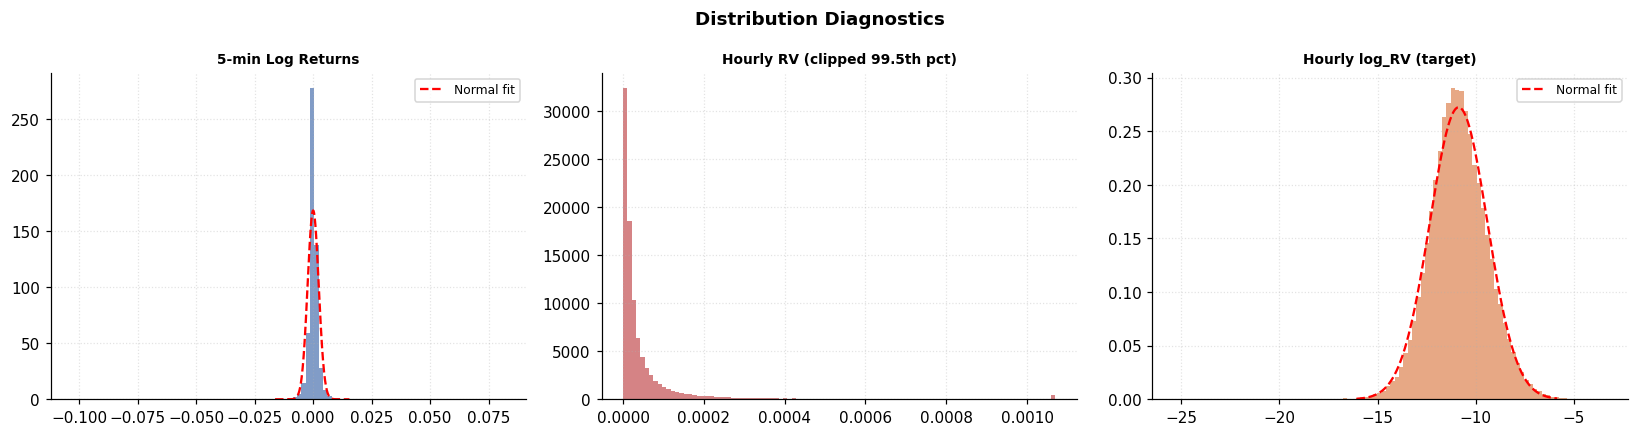

In [131]:
# Distribution diagnostics 

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ser, colour, title in [
    (axes[0], returns, "#4C72B0", "5-min Log Returns"),
    (axes[1], rv_ser.clip(upper=rv_ser.quantile(0.995)),
              "#C44E52", "Hourly RV (clipped 99.5th pct)"),
    (axes[2], logrv,   "#DD8452", "Hourly log_RV (target)"),
]:
    ax.hist(ser.dropna(), bins=100, density=True, color=colour, alpha=0.7)
    if title != "Hourly RV (clipped 99.5th pct)":
        xs = np.linspace(ser.dropna().quantile(0.001),
                         ser.dropna().quantile(0.999), 300)
        ax.plot(xs, _norm.pdf(xs, ser.mean(), ser.std()),
                "r--", lw=1.5, label="Normal fit")
        ax.legend(fontsize=8)
    ax.set_title(f"{title}", fontweight="bold", fontsize=9)
    
plt.suptitle("Distribution Diagnostics", fontweight="bold")
plt.tight_layout()
plt.show()

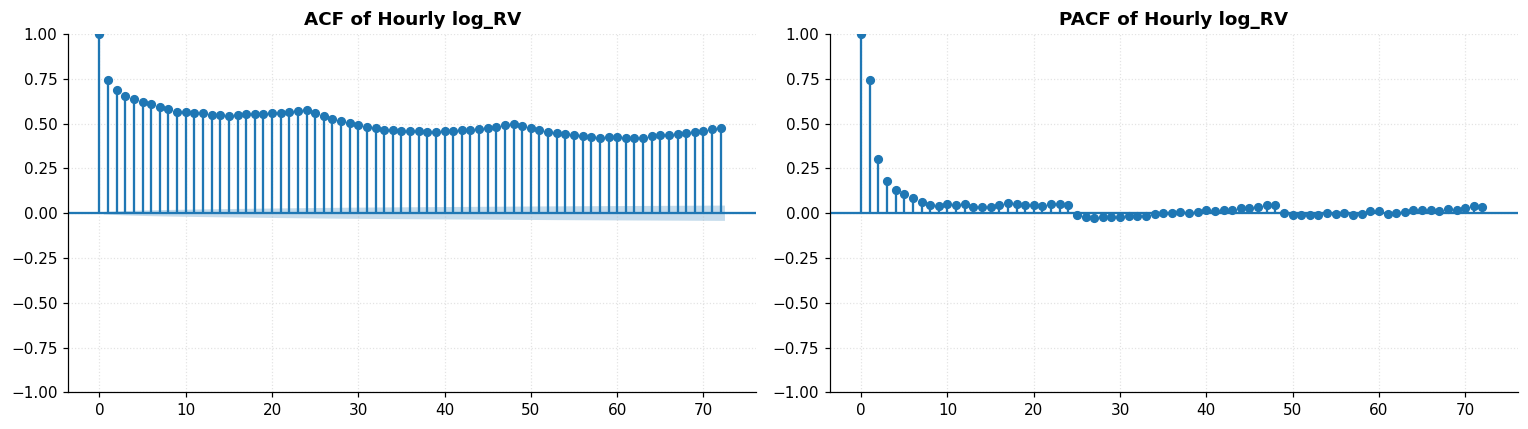

In [132]:
# ACF / PACF 

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(logrv,  lags=72, alpha=0.05, ax=axes[0])
axes[0].set_title("ACF of Hourly log_RV", fontweight="bold")
plot_pacf(logrv, lags=72, method="ywm", alpha=0.05, ax=axes[1])
axes[1].set_title("PACF of Hourly log_RV", fontweight="bold")
plt.tight_layout()
plt.show()

- ##### ACF (Autocorrelation Function)

The ACF shows how strongly a time series is correlated with its own past values. In other words, it answers the question: *"How similar is today's log_RV to the value observed k hours ago?"*

In this case, the ACF starts at about 0.74 for lag 1 and remains significant even after 72 hours (3 days), where it is still around 0.50. This very slow decline indicates strong persistence over time. If the series were just random noise, the autocorrelations would quickly drop to zero. Instead, volatility remains highly correlated with its past values for several days.

In practical terms, when volatility becomes high, it tends to stay high for a long period rather than returning immediately to normal levels. This is a typical sign of long memory in volatility.

- ##### PACF (Partial Autocorrelation Function)

The PACF measures the direct relationship between the current value and a past value after removing the effects of the intermediate lags.

Here, the PACF is about 0.74 at lag 1 and drops to around 0.26 at lag 2. After lag 3, the values are close to zero. This suggests that the direct dependence is concentrated mainly in the first one or two lags.

- ##### What Do These Results Mean Together?

The combination of a slowly decaying ACF and a PACF that cuts off after lag 2 suggests that the apparent long memory is mainly driven by short-term dependencies that propagate through time.

In other words, today's volatility is strongly influenced by yesterday's volatility, which was influenced by the day before, and so on. The persistence observed over several days is therefore largely an indirect effect of these short-run relationships, rather than a direct influence of volatility from three days ago on today's volatility.


In [133]:
# Stationarity & ARCH 

adf = adfuller(logrv.dropna(), autolag="AIC")
print(f"\n  ADF test (log_RV): stat={adf[0]:.4f}  p={adf[1]:.4g}  "
      f"→ {'stationary' if adf[1] < 0.05 else 'non-stationary'}")
 
arch_test = het_arch(hourly_ret.dropna(), nlags=24)
print(f"  ARCH LM (24 lags): stat={arch_test[0]:.4f}  p={arch_test[1]:.4g}  "
      f" ARCH effects {'present' if arch_test[1] < 0.05 else 'absent'}")


  ADF test (log_RV): stat=-13.3256  p=6.331e-25  → stationary
  ARCH LM (24 lags): stat=9932.0097  p=0   ARCH effects present


##### ADF Test >>>> Is log_RV Stationary?
Result: stat = −13.33 | p ≈ 6.3 × 10⁻²⁵ →  Stationary

The null hypothesis of a unit root is decisively rejected.log_RV does not drift over time it fluctuates around a stable mean. This is a prerequisite for reliable OLS, GARCH, and LSTM estimation.

##### 2. ARCH LM Test >>> Does Volatility Cluster?
Result: stat = 9932 | p ≈ 0 →  ARCH effects present

The null hypothesis of constant variance is decisively rejected. Periods of high volatility tend to be followed by high volatility and vice versa.  This volatility clustering is the core motivation for the MC-GARCH model.

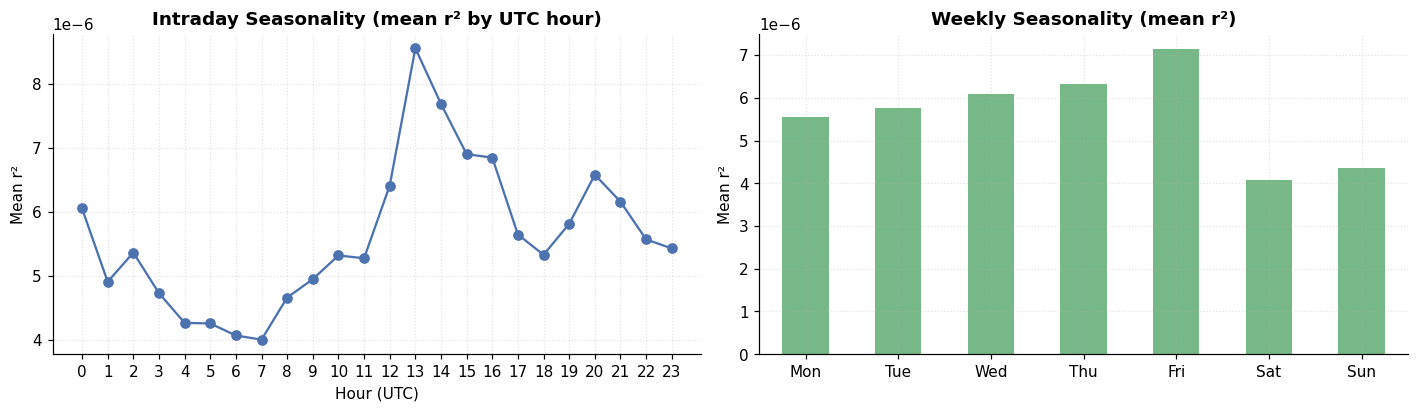

In [134]:
# Intraday / weekly seasonality 

intra = raw[["r2_5m"]].dropna().copy()
intra["hour_utc"] = intra.index.hour
intra["weekday"]  = intra.index.dayofweek
h_prof = intra.groupby("hour_utc")["r2_5m"].mean()
d_prof = intra.groupby("weekday")["r2_5m"].mean()
d_prof.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
h_prof.plot(marker="o", color="#4C72B0", lw=1.5, ax=axes[0])
axes[0].set_title("Intraday Seasonality (mean r² by UTC hour)",
                  fontweight="bold")

axes[0].set_xlabel("Hour (UTC)"); axes[0].set_ylabel("Mean r²")
axes[0].set_xticks(range(24))
d_prof.plot(kind="bar", color="#55A868", alpha=0.8, rot=0, ax=axes[1])
axes[1].set_title("Weekly Seasonality (mean r²)", fontweight="bold")
axes[1].set_ylabel("Mean r²")

plt.tight_layout()
plt.show()

- ##### Intraday Pattern

Bitcoin volatility follows a distinct daily cycle. The lowest volatility is observed around 07:00 UTC, when Asian markets are closing and European markets have not yet fully opened. Market activity is relatively subdued during this period, resulting in smaller price fluctuations.

Volatility rises throughout the day and reaches its peak around 13:00 UTC, nearly doubling its minimum level. This peak coincides with the London–New York market overlap, the most active trading window in global financial markets. The concentration of institutional trading and increased order flow during this period appears to spill over into the Bitcoin market, generating larger price movements.

- ##### Weekly Pattern

A similar pattern emerges across the week. Friday consistently records the highest volatility, likely reflecting institutional investors adjusting or unwinding positions before the weekend. Increased portfolio rebalancing and risk management activity contribute to stronger market fluctuations.

In contrast, Saturday and Sunday are the least volatile days of the week. Despite Bitcoin's continuous trading schedule, reduced participation from institutional investors during the weekend leads to lower market activity and calmer price dynamics.

- ##### Implications for Modelling

These recurring patterns indicate that calendar effects contain valuable predictive information and should be incorporated into volatility forecasting models. To capture these cyclical behaviors, the LSTM model includes time-based features:

* hour_sin and hour_cos represent intraday cycles and allow the model to learn hour-of-day effects.
* dow_sin and dow_cos represent weekly cycles and capture day-of-week seasonality.

By incorporating these features, the model can better account for systematic variations in volatility associated with trading activity across different hours and days.
